In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
from scipy.stats import pearsonr
import xgboost as xgb

from textblob import TextBlob
from skopt.space import Integer, Real
from skopt import BayesSearchCV

In [55]:
df = pd.read_csv('/Users/ansonliu/Github/movie_behavioural_disagreements/data/model/model_input_df.csv')
df.head()

,id,title,release_date,revenue,budget,genres,production_companies,production_countries,keywords,overview,release_year,Tomatometer,Popcornmeter
0,27205,Inception,2010-07-15,825532764,160000000,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc...","Cobb, a skilled thief who commits corporate es...",2010,87,91
1,157336,Interstellar,2014-11-05,701729206,165000000,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,...",The adventures of a group of explorers who mak...,2014,73,87
2,155,The Dark Knight,2008-07-16,1004558444,185000000,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f...",Batman raises the stakes in his war on crime. ...,2008,94,94
3,19995,Avatar,2009-12-15,2923706026,237000000,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ...","In the 22nd century, a paraplegic Marine is di...",2009,81,82
4,293660,Deadpool,2016-02-09,783100000,58000000,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,"superhero, anti hero, mercenary, based on comi...",The origin story of former Special Forces oper...,2016,85,90


In [56]:
df.loc[df['genres'].str.contains('documentary', case=False)].head()

,id,title,release_date,revenue,budget,genres,production_companies,production_countries,keywords,overview,release_year,Tomatometer,Popcornmeter
1704,9372,Super Size Me,2004-01-17,28575078,65000,Documentary,"Kathbur Pictures, Samuel Goldwyn Films, The Co...",United States of America,"experiment, diet, junk food, health, food indu...",Morgan Spurlock subjects himself to a diet bas...,2004,92,72
1753,9012,Jackass: The Movie,2002-10-25,64282312,5000000,"Comedy, Documentary","Lynch Siderow Productions, Dickhouse Productio...",United States of America,"pain, idiot, disgust, stunt, music video, stun...",Johnny Knoxville and his band of maniacs perfo...,2002,49,75
1779,1430,Bowling for Columbine,2002-10-09,35564473,4000000,"Documentary, Drama",Vif Babelsberger Filmproduktion GmbH & Co. Zwe...,"Canada, Germany, United States of America","canada, gun, homicide, mass murder, oklahoma c...",This is not a film about gun control. It is a ...,2002,95,83
1868,1777,Fahrenheit 9/11,2004-06-25,222446882,6000000,Documentary,"Fellowship Adventure Group, BIM Distribuzione,...",United States of America,"saudi arabia, usa president, government, war o...",Michael Moore's view on how the Bush administr...,2004,82,70
1902,16290,Jackass 3D,2010-10-15,117224271,20000000,"Comedy, Documentary, Action","MTV Films, Dickhouse Productions, Paramount",United States of America,"pain, stunt, stuntman, stupidity, duringcredit...","Johnny Knoxville, Bam Margera, Steve-O, Wee Ma...",2010,67,69


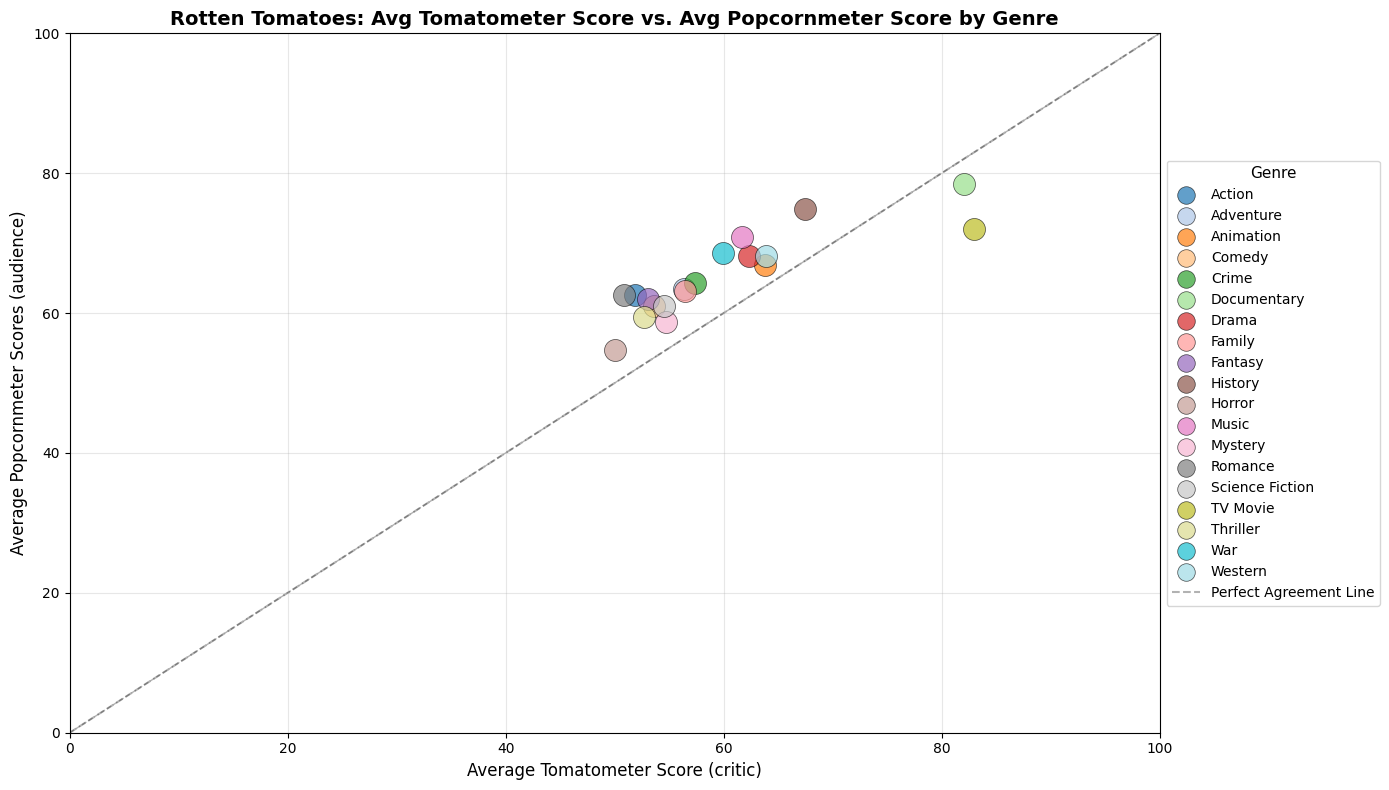


Genre Statistics:
              genre    avg_ttm    avg_ppm   abs_diff
13          Romance  50.847145  62.653775  11.806630
15         TV Movie  83.000000  72.000000  11.000000
0            Action  51.829211  62.520612  10.691402
11            Music  61.693694  70.882883   9.189189
8           Fantasy  53.029570  62.045699   9.016129
17              War  59.977528  68.651685   8.674157
3            Comedy  53.570069  61.026817   7.456747
9           History  67.446541  74.899371   7.452830
1         Adventure  56.344262  63.451565   7.107303
4             Crime  57.360440  64.259341   6.898901
7            Family  56.449761  63.172249   6.722488
16         Thriller  52.716507  59.427033   6.710526
14  Science Fiction  54.536785  61.076294   6.539510
6             Drama  62.318011  68.113791   5.795780
10           Horror  50.031977  54.709302   4.677326
18          Western  63.875000  68.156250   4.281250
12          Mystery  54.692580  58.770318   4.077739
5       Documentary  82.081

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_exploded = df[['genres', 'Tomatometer', 'Popcornmeter']].copy()

# Split genres by comma and create separate rows
df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres')

# Remove any leading/trailing whitespace from genre names
df_exploded['genres'] = df_exploded['genres'].str.strip()

# Calculate average scores by genre
genre_stats = df_exploded.groupby('genres').agg({
    'Tomatometer': 'mean',
    'Popcornmeter': 'mean'
}).reset_index()

genre_stats.columns = ['genre', 'avg_ttm', 'avg_ppm']

# Create the scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

# Generate distinguishable colors for each genre
n_genres = len(genre_stats)
if n_genres <= 10:
    colours = plt.cm.tab10(np.linspace(0, 1, n_genres))
elif n_genres <= 20:
    colours = plt.cm.tab20(np.linspace(0, 1, n_genres))
else:
    # For more genres, use hsv colormap
    colours = plt.cm.hsv(np.linspace(0, 0.9, n_genres))

for idx, row in genre_stats.iterrows():
    ax.scatter(row['avg_ttm'], row['avg_ppm'], 
                s=250, alpha=0.7, color=colours[idx], 
                edgecolors='black', linewidth=0.5,
                label=row['genre'], zorder=2)

genre_stats['abs_diff'] = abs(genre_stats['avg_ttm'] - genre_stats['avg_ppm'])

ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, linewidth=1, zorder=1)

ax.set_xlabel('Average Tomatometer Score (critic)', fontsize=12)
ax.set_ylabel('Average Popcornmeter Scores (audience)', fontsize=12)
ax.set_title('Rotten Tomatoes: Avg Tomatometer Score vs. Avg Popcornmeter Score by Genre', 
          fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, zorder=0)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, linewidth=1.5, label='Perfect Agreement Line', zorder=1)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), 
         frameon=True, fontsize=10, title='Genre',
         title_fontsize=11, markerscale=0.8)

plt.tight_layout()
plt.show()

# Display the data table
print("\nGenre Statistics:")
print(genre_stats.sort_values('abs_diff', ascending=False))

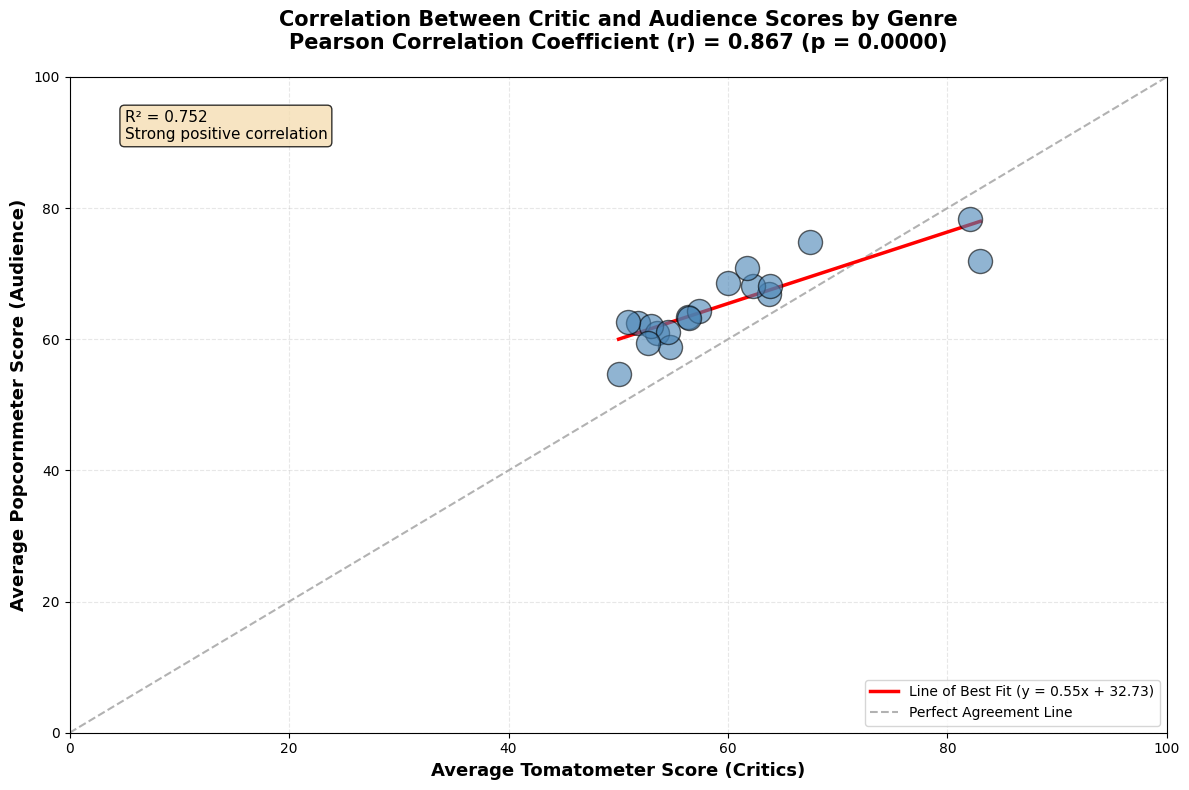


=== Correlation Analysis ===
Pearson Correlation Coefficient (r): 0.8672
P-value: 0.000002
R² (Coefficient of Determination): 0.7520
Slope: 0.5452
Intercept: 32.7331

Interpretation: Strong positive correlation


In [58]:
df_pmcc = df[['genres', 'Tomatometer', 'Popcornmeter']].copy()

# Split genres by comma and create separate rows
df_pmcc['genres'] = df_pmcc['genres'].str.split(', ')
df_pmcc = df_pmcc.explode('genres')

# Remove any leading/trailing whitespace from genre names
df_pmcc['genres'] = df_pmcc['genres'].str.strip()

# Calculate average scores by genre
genre_stats = df_pmcc.groupby('genres').agg({
    'Tomatometer': 'mean',
    'Popcornmeter': 'mean'
}).reset_index()

genre_stats.columns = ['genre', 'avg_ttm', 'avg_ppm']

# Calculate Pearson correlation coefficient
correlation = pearsonr(genre_stats['avg_ttm'], genre_stats['avg_ppm'])
r_value = correlation[0]
p_value = correlation[1]

# Calculate line of best fit
slope, intercept = np.polyfit(genre_stats['avg_ttm'], genre_stats['avg_ppm'], 1)
line_x = np.array([genre_stats['avg_ttm'].min(), genre_stats['avg_ttm'].max()])
line_y = slope * line_x + intercept

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
ax.scatter(genre_stats['avg_ttm'], genre_stats['avg_ppm'], 
          s=300, alpha=0.6, color='steelblue', 
          edgecolors='black', linewidth=1, zorder=3)

# Add line of best fit
ax.plot(line_x, line_y, 'r-', linewidth=2.5, label=f'Line of Best Fit (y = {slope:.2f}x + {intercept:.2f})', zorder=2)

ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, linewidth=1.5, label='Perfect Agreement Line', zorder=1)

# Customize plot
ax.set_xlabel('Average Tomatometer Score (Critics)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Popcornmeter Score (Audience)', fontsize=13, fontweight='bold')
ax.set_title(f'Correlation Between Critic and Audience Scores by Genre\nPearson Correlation Coefficient (r) = {r_value:.3f} (p = {p_value:.4f})', 
          fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

# Add text box with interpretation
interpretation = f"R² = {r_value**2:.3f}\n"
if r_value > 0.7:
    interpretation += "Strong positive correlation"
elif r_value > 0.4:
    interpretation += "Moderate positive correlation"
elif r_value > 0:
    interpretation += "Weak positive correlation"
elif r_value > -0.4:
    interpretation += "Weak negative correlation"
elif r_value > -0.7:
    interpretation += "Moderate negative correlation"
else:
    interpretation += "Strong negative correlation"

ax.text(0.05, 0.95, interpretation, transform=ax.transAxes, 
       fontsize=11, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Add legend
ax.legend(loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

# Display statistics
print("\n=== Correlation Analysis ===")
print(f"Pearson Correlation Coefficient (r): {r_value:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"R² (Coefficient of Determination): {r_value**2:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"\nInterpretation: {interpretation.split(chr(10))[1]}")

In [59]:
reg_df = df.copy()
reg_df.head()

,id,title,release_date,revenue,budget,genres,production_companies,production_countries,keywords,overview,release_year,Tomatometer,Popcornmeter
0,27205,Inception,2010-07-15,825532764,160000000,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc...","Cobb, a skilled thief who commits corporate es...",2010,87,91
1,157336,Interstellar,2014-11-05,701729206,165000000,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,...",The adventures of a group of explorers who mak...,2014,73,87
2,155,The Dark Knight,2008-07-16,1004558444,185000000,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f...",Batman raises the stakes in his war on crime. ...,2008,94,94
3,19995,Avatar,2009-12-15,2923706026,237000000,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ...","In the 22nd century, a paraplegic Marine is di...",2009,81,82
4,293660,Deadpool,2016-02-09,783100000,58000000,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,"superhero, anti hero, mercenary, based on comi...",The origin story of former Special Forces oper...,2016,85,90


# REGRESSION

In [61]:
# Remove rows with missing target variables
reg_df = reg_df.dropna(subset=['Tomatometer', 'Popcornmeter'])

# Feature Engineering
print("=== Feature Engineering ===")

# 1. Log-transform revenue and budget (handle zeros/nulls)
reg_df['log_revenue'] = np.log1p(reg_df['revenue'].fillna(0))
reg_df['log_budget'] = np.log1p(reg_df['budget'].fillna(0))

# 2. Budget-to-revenue ratio (ROI indicator)
reg_df['roi'] = reg_df['revenue'] / (reg_df['budget'] + 1)  # Add 1 to avoid division by zero
reg_df['log_roi'] = np.log1p(reg_df['roi'])

# 3. Production countries count
reg_df['num_countries'] = reg_df['production_countries'].str.split(',').str.len()
reg_df['num_countries'] = reg_df['num_countries'].fillna(0)

# 4. Genres - Group into broader categories
genres_exploded = reg_df['genres'].str.split(', ').explode()
genres_exploded = genres_exploded.str.strip()
unique_genres = genres_exploded[genres_exploded.notna()].unique()

print(f"Found {len(unique_genres)} unique genres: {sorted(unique_genres)}")

# Ensure genres column is string
reg_df['genres'] = reg_df['genres'].fillna('')

# Create binary indicator for each genre
for genre in unique_genres:
    genre_safe = genre.replace(' ', '_').replace('/', '_')  # Make column name safe
    pattern = r'\b' + re.escape(genre) + r'\b'
    reg_df[f'genre_{genre_safe}'] = (
        reg_df['genres']
        .str.contains(pattern, case=False, regex=True)
        .astype(int)
    )

genre_columns = [f'genre_{genre.replace(" ", "_").replace("/", "_")}' for genre in unique_genres]

# 5. companies dummies
top_n_companies = 30

companies_exploded = reg_df['production_companies'].str.split(', ').explode()
top_companies = companies_exploded.value_counts().head(top_n_companies).index
reg_df['production_companies_list'] = reg_df['production_companies'].str.split(', ')

# Create binary feature: 1 if made by a top company, 0 otherwise
reg_df['is_top_studio'] = reg_df['production_companies_list'].apply(
    lambda x: 1 if isinstance(x, list) and any(company in top_companies for company in x) else 0
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# For each movie overview
reg_df['overview_sentiment'] = reg_df['overview'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

reg_df['keywords_sentiment'] = reg_df['keywords'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# # Overview sentiment
# reg_df['overview_sentiment'] = reg_df['overview'].apply(
#     lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0
# )

# # Keywords sentiment (if they're descriptive words)
# reg_df['keywords_sentiment'] = reg_df['keywords'].apply(
#     lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0
# )

# Combine all features
sentiment_columns = ['keywords_sentiment', 'overview_sentiment']
num_columns = ['budget']
binary_columns = ['is_top_studio']
feature_columns = num_columns + binary_columns + genre_columns + sentiment_columns

print(f"\nTotal features: {len(feature_columns)}")
print(f"- Numerical: {len(num_columns)}")
print(f"- Binary: {len(binary_columns)}")
print(f"- Genre Groups: {len(genre_columns)}")

# Prepare X and y
X = reg_df[feature_columns].fillna(0)
y_tomatometer = reg_df['Tomatometer']
y_popcornmeter = reg_df['Popcornmeter']

X_train, X_test, y_tom_train, y_tom_test = train_test_split(
    X, y_tomatometer, test_size=0.2, random_state=42
)
_, _, y_pop_train, y_pop_test = train_test_split(
    X, y_popcornmeter, test_size=0.2, random_state=42
)

# Standardize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X.head()

=== Feature Engineering ===
Found 19 unique genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

Total features: 23
- Numerical: 1
- Binary: 1
- Genre Groups: 19


,budget,is_top_studio,genre_Action,genre_Science_Fiction,genre_Adventure,genre_Drama,genre_Crime,genre_Thriller,genre_Fantasy,genre_Comedy,...,genre_Animation,genre_Family,genre_Music,genre_Horror,genre_History,genre_Romance,genre_TV_Movie,genre_Documentary,keywords_sentiment,overview_sentiment
0,160000000,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.3400,-0.3182
1,165000000,1,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.8750,0.3400
2,185000000,1,1,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,-0.9118,-0.9607
3,237000000,1,1,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0.0000,-0.3612
4,58000000,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0.3182,0.5106


In [62]:
print("\n=== Ridge Regression Hyperparameter Tuning ===")
print("Testing different regularization strengths (alpha)...")

# Define parameter grid for Ridge
# Alpha controls regularization strength: higher = more regularization
param_grid = {
    'alpha': [0.01, 0.1, 0.25, 0.5],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga'],
    'fit_intercept': [True, False],
    'max_iter': [500, 1000, 2000, 3000, 4000, 5000, 10000]
}

# GridSearchCV for Tomatometer
print("\n--- Tuning Tomatometer Ridge model ---")
ridge_base = Ridge(random_state=42)
grid_search_tom = GridSearchCV(
    estimator=ridge_base,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1
)

grid_search_tom.fit(X_train_scaled, y_tom_train)

print(f"\nBest Tomatometer Parameters: {grid_search_tom.best_params_}")
print(f"Best CV R² Score: {grid_search_tom.best_score_:.4f}")

# GridSearchCV for Popcornmeter
print("\n--- Tuning Popcornmeter Ridge model ---")
grid_search_pop = GridSearchCV(
    estimator=ridge_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_pop.fit(X_train_scaled, y_pop_train)

print(f"\nBest Popcornmeter Parameters: {grid_search_pop.best_params_}")
print(f"Best CV R² Score: {grid_search_pop.best_score_:.4f}")

# Use best models
ridge_tom = grid_search_tom.best_estimator_
ridge_pop = grid_search_pop.best_estimator_

# Predictions
y_tom_pred = ridge_tom.predict(X_test_scaled)
y_pop_pred = ridge_pop.predict(X_test_scaled)

# Evaluate models
print("\n=== TOMATOMETER Model Performance (After Tuning) ===")
tom_r2 = r2_score(y_tom_test, y_tom_pred)
tom_mae = mean_absolute_error(y_tom_test, y_tom_pred)
tom_rmse = np.sqrt(mean_squared_error(y_tom_test, y_tom_pred))
print(f"R² Score: {tom_r2:.4f}")
print(f"MAE: {tom_mae:.4f}")
print(f"RMSE: {tom_rmse:.4f}")

print("\n=== POPCORNMETER Model Performance (After Tuning) ===")
pop_r2 = r2_score(y_pop_test, y_pop_pred)
pop_mae = mean_absolute_error(y_pop_test, y_pop_pred)
pop_rmse = np.sqrt(mean_squared_error(y_pop_test, y_pop_pred))
print(f"R² Score: {pop_r2:.4f}")
print(f"MAE: {pop_mae:.4f}")
print(f"RMSE: {pop_rmse:.4f}")

# Training vs Test R² (check for overfitting)
y_tom_train_pred = ridge_tom.predict(X_train_scaled)
y_pop_train_pred = ridge_pop.predict(X_train_scaled)

print("\n=== Training vs Test Performance (Overfitting Check) ===")
print("Tomatometer R² (train):", r2_score(y_tom_train, y_tom_train_pred))
print("Tomatometer R² (test):", r2_score(y_tom_test, y_tom_pred))

print("\nPopcornmeter R² (train):", r2_score(y_pop_train, y_pop_train_pred))
print("Popcornmeter R² (test):", r2_score(y_pop_test, y_pop_pred))



=== Ridge Regression Hyperparameter Tuning ===
Testing different regularization strengths (alpha)...

--- Tuning Tomatometer Ridge model ---

Best Tomatometer Parameters: {'alpha': 0.5, 'fit_intercept': True, 'max_iter': 500, 'solver': 'saga'}
Best CV R² Score: 0.1116

--- Tuning Popcornmeter Ridge model ---
Fitting 5 folds for each of 280 candidates, totalling 1400 fits

Best Popcornmeter Parameters: {'alpha': 0.5, 'fit_intercept': True, 'max_iter': 500, 'solver': 'saga'}
Best CV R² Score: 0.1142

=== TOMATOMETER Model Performance (After Tuning) ===
R² Score: 0.1168
MAE: 21.2071
RMSE: 24.7359

=== POPCORNMETER Model Performance (After Tuning) ===
R² Score: 0.1454
MAE: 14.5772
RMSE: 17.3603

=== Training vs Test Performance (Overfitting Check) ===
Tomatometer R² (train): 0.13520355812958795
Tomatometer R² (test): 0.11684973292425072

Popcornmeter R² (train): 0.13955202429456615
Popcornmeter R² (test): 0.1453777330012912


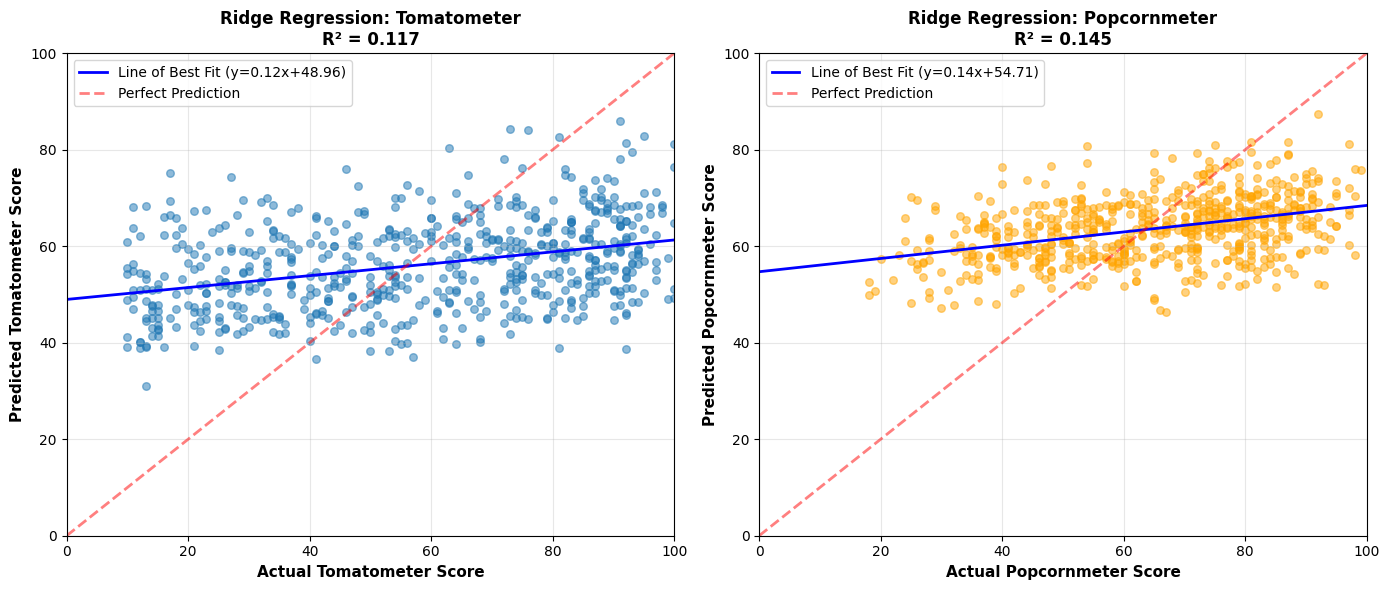


=== Best Parameters Summary ===

Tomatometer Ridge:
  alpha: 0.5
  fit_intercept: True
  max_iter: 500
  solver: saga

Popcornmeter Ridge:
  alpha: 0.5
  fit_intercept: True
  max_iter: 500
  solver: saga


In [63]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tomatometer plot
axes[0].scatter(y_tom_test, y_tom_pred, alpha=0.5, s=30)

# Calculate line of best fit for Tomatometer
slope_tom, intercept_tom = np.polyfit(y_tom_test, y_tom_pred, 1)
line_x = np.array([0, 100])
line_y_tom = slope_tom * line_x + intercept_tom
axes[0].plot(line_x, line_y_tom, 'b-', linewidth=2, label=f'Line of Best Fit (y={slope_tom:.2f}x+{intercept_tom:.2f})')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, alpha=0.5, label='Perfect Prediction')

axes[0].set_xlabel('Actual Tomatometer Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Tomatometer Score', fontsize=11, fontweight='bold')
axes[0].set_title(f'Ridge Regression: Tomatometer\nR² = {tom_r2:.3f}', 
                 fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Popcornmeter plot
axes[1].scatter(y_pop_test, y_pop_pred, alpha=0.5, s=30, color='orange')

# Calculate line of best fit for Popcornmeter
slope_pop, intercept_pop = np.polyfit(y_pop_test, y_pop_pred, 1)
line_y_pop = slope_pop * line_x + intercept_pop
axes[1].plot(line_x, line_y_pop, 'b-', linewidth=2, label=f'Line of Best Fit (y={slope_pop:.2f}x+{intercept_pop:.2f})')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=2, alpha=0.5, label='Perfect Prediction')

axes[1].set_xlabel('Actual Popcornmeter Score', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Popcornmeter Score', fontsize=11, fontweight='bold')
axes[1].set_title(f'Ridge Regression: Popcornmeter\nR² = {pop_r2:.3f}', 
                 fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\n=== Best Parameters Summary ===")
print(f"\nTomatometer Ridge:")
for param, value in grid_search_tom.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nPopcornmeter Ridge:")
for param, value in grid_search_pop.best_params_.items():
    print(f"  {param}: {value}")

In [64]:
tom_coefs = ridge_tom.coef_
tom_intercept = ridge_tom.intercept_

pop_coefs = ridge_pop.coef_
pop_intercept = ridge_pop.intercept_

coef_df = pd.DataFrame({
    "feature": X.columns,
    "tomatometer_coef": tom_coefs,
    "popcornmeter_coef": pop_coefs
})

coef_df['combined_abs_importance'] = abs(coef_df['tomatometer_coef'] - coef_df['popcornmeter_coef'])

coef_df = coef_df.sort_values(by=['combined_abs_importance'], ascending=False)

coef_df


,feature,tomatometer_coef,popcornmeter_coef,combined_abs_importance
19,genre_TV_Movie,21.851702,5.861192,15.990510
20,genre_Documentary,26.654355,15.215871,11.438484
13,genre_Animation,13.068258,6.152521,6.915736
10,genre_Western,8.982843,2.501979,6.480863
18,genre_Romance,-8.286299,-2.140377,6.145922
2,genre_Action,-6.548043,-1.450257,5.097786
5,genre_Drama,11.375833,6.531502,4.844331
3,genre_Science_Fiction,1.307813,-2.759040,4.066853
1,is_top_studio,-6.057862,-2.404711,3.653151
14,genre_Family,-6.077760,-2.518718,3.559042


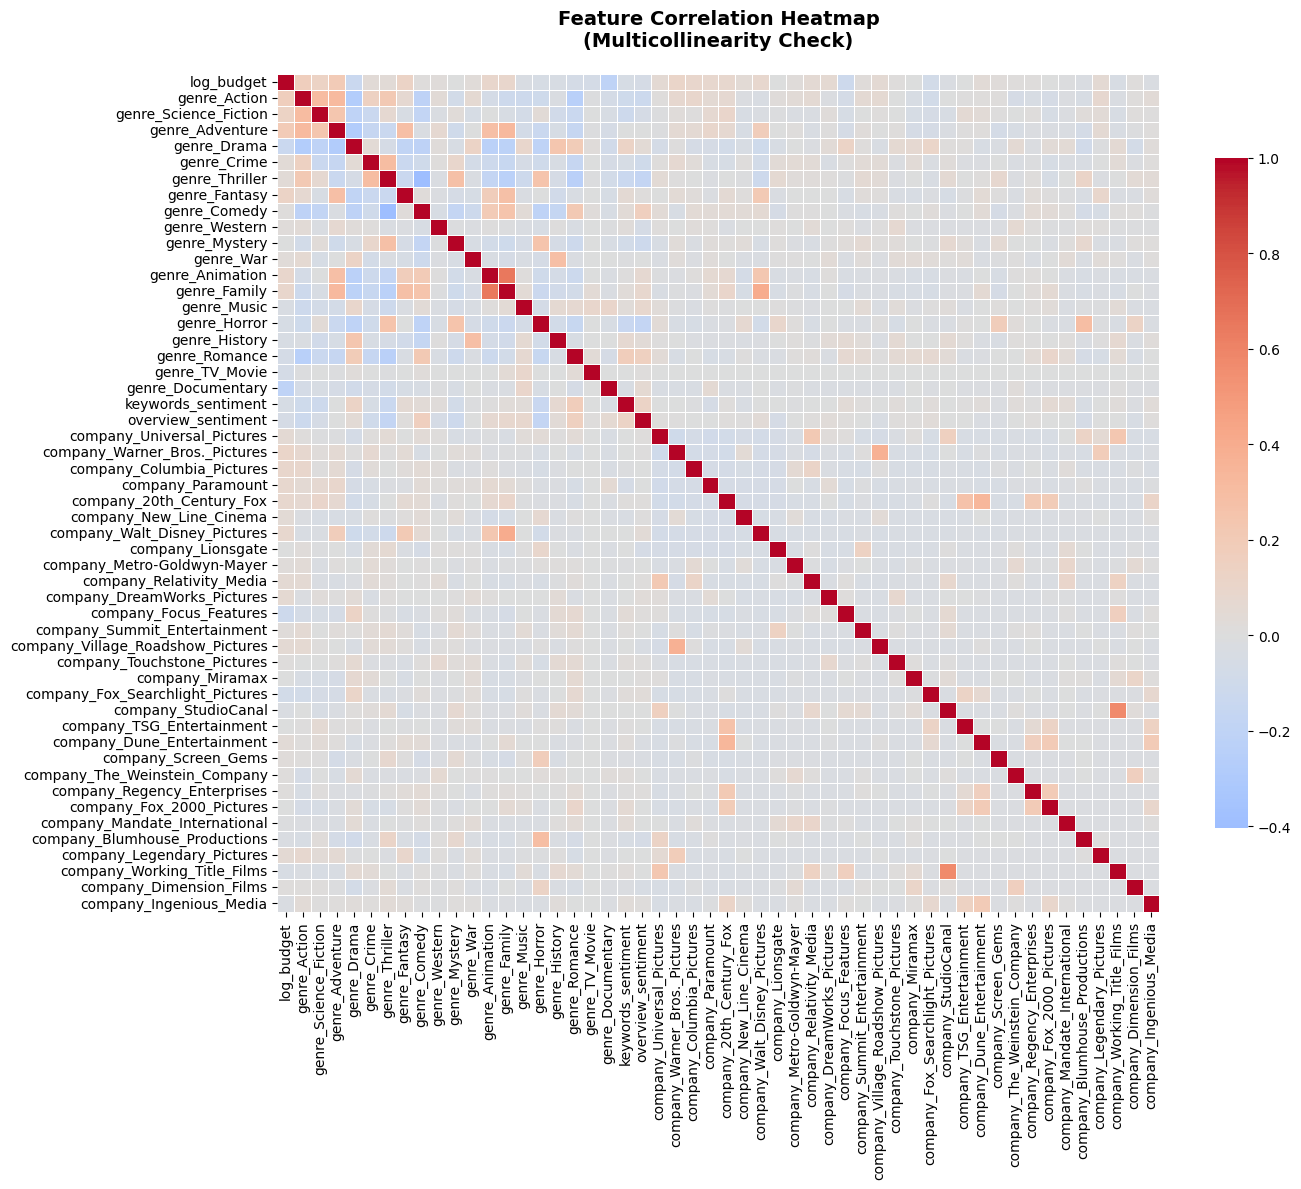

In [16]:
corr_matrix = X.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap\n(Multicollinearity Check)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# XGBOOST

In [ ]:
# Prepare the data
xgb_df = reg_df.copy()

# Remove rows with missing target variables
xgb_df = xgb_df.dropna(subset=['Tomatometer', 'Popcornmeter'])

# Feature Engineering
print("=== Feature Engineering ===")

# 1. Log-transform revenue and budget (handle zeros/nulls)
xgb_df['log_revenue'] = np.log1p(xgb_df['revenue'].fillna(0))
xgb_df['log_budget'] = np.log1p(xgb_df['budget'].fillna(0))

# 2. Budget-to-revenue ratio (ROI indicator)
xgb_df['roi'] = xgb_df['revenue'] / (xgb_df['budget'] + 1)  # Add 1 to avoid division by zero
xgb_df['log_roi'] = np.log1p(xgb_df['roi'])

# 3. Production countries count
xgb_df['num_countries'] = xgb_df['production_countries'].str.split(',').str.len()
xgb_df['num_countries'] = xgb_df['num_countries'].fillna(0)

# 4. Genres as dummy variables
genres_exploded = xgb_df['genres'].str.split(', ').explode()
genre_dummies = pd.get_dummies(genres_exploded, prefix='genre').groupby(level=0).sum()
genre_dummies = genre_dummies.clip(upper=1)  # Convert counts to binary

# 5. Production companies - keep only top N most frequent
print("\nProcessing production companies...")
top_n_companies = 30  # Adjust this number

companies_exploded = xgb_df['production_companies'].str.split(', ').explode()
top_companies = companies_exploded.value_counts().head(top_n_companies).index
xgb_df['production_companies_list'] = xgb_df['production_companies'].str.split(', ')

for company in top_companies:
    xgb_df[f'company_{company}'] = xgb_df['production_companies_list'].apply(
        lambda x: 1 if isinstance(x, list) and company in x else 0
    )

# Combine all features
feature_columns = ['log_revenue', 'log_budget', 'log_roi', 'num_countries']
feature_columns += [col for col in xgb_df.columns if col.startswith('company_')]

# Add genre dummies
xgb_df = xgb_df.join(genre_dummies)
feature_columns += list(genre_dummies.columns)

print(f"\nTotal features: {len(feature_columns)}")
print(f"- Numerical: 4")
print(f"- Companies: {len([c for c in feature_columns if c.startswith('company_')])}")
print(f"- Genres: {len([c for c in feature_columns if c.startswith('genre_')])}")

# Prepare X and y
X = xgb_df[feature_columns].fillna(0)
y_tomatometer = xgb_df['Tomatometer']
y_popcornmeter = xgb_df['Popcornmeter']

# Train-test split
X_train, X_test, y_tom_train, y_tom_test = train_test_split(
    X, y_tomatometer, test_size=0.2, random_state=42
)
_, _, y_pop_train, y_pop_test = train_test_split(
    X, y_popcornmeter, test_size=0.2, random_state=42
)


=== Feature Engineering ===

Processing production companies...

Total features: 53
- Numerical: 4
- Companies: 30
- Genres: 19


In [65]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

search_space = {
    'n_estimators': Integer(100, 300),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'max_depth': Integer(2, 5),
    'min_child_weight': Integer(1, 5),
    'subsample': Real(0.8, 1.0),
    'colsample_bytree': Real(0.8, 1.0),
    'gamma': Real(0.0, 0.2)
}


# Initialize base models
base_model = xgb.XGBRegressor(random_state=42, n_jobs=1)  # n_jobs=1 for GridSearchCV compatibility


# GridSearchCV for Tomatometer
print("\n--- Tuning Tomatometer model ---")
# grid_search_tom = GridSearchCV(
#     estimator=base_model,
#     param_grid=param_grid,
#     cv=5,  # 5-fold cross-validation
#     scoring='r2',
#     n_jobs=-1,  # Use all CPU cores
#     verbose=1
# )
grid_search_tom = BayesSearchCV(
    base_model,
    search_space,
    n_iter=30,
    cv=5,
    scoring='r2',
    refit=True,
    verbose=1
)

grid_search_tom.fit(X_train_scaled, y_tom_train)

print(f"\nBest Tomatometer Parameters: {grid_search_tom.best_params_}")
print(f"Best CV R² Score: {grid_search_tom.best_score_:.4f}")

# GridSearchCV for Popcornmeter
print("\n--- Tuning Popcornmeter model ---")
grid_search_pop = BayesSearchCV(
    base_model,
    search_space,
    n_iter=30,
    cv=5,
    scoring='r2',
    refit=True,
    verbose=1
)

# grid_search_pop = GridSearchCV(
#     estimator=base_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=1
# )

grid_search_pop.fit(X_train_scaled, y_pop_train)

print(f"\nBest Popcornmeter Parameters: {grid_search_pop.best_params_}")
print(f"Best CV R² Score: {grid_search_pop.best_score_:.4f}")

# Use best models
gb_tom = grid_search_tom.best_estimator_
gb_pop = grid_search_pop.best_estimator_

# Predictions
y_tom_pred = gb_tom.predict(X_test_scaled)
y_pop_pred = gb_pop.predict(X_test_scaled)


--- Tuning Tomatometer model ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for ea


=== TOMATOMETER Model Performance ===
R² Score: 0.1672
MAE: 20.4269
RMSE: 24.0199

=== POPCORNMETER Model Performance ===
R² Score: 0.1593
MAE: 14.4108
RMSE: 17.2181

=== Top 15 Features with LARGEST DIFFERENCES ===
(These drive critics and audiences differently)
                  Feature  Tomatometer_Importance  Popcornmeter_Importance  Abs_Diff
16           genre_Horror                0.041154                 0.085790  0.044636
5             genre_Drama                0.152884                 0.190729  0.037845
18          genre_Romance                0.064676                 0.032377  0.032299
7          genre_Thriller                0.038328                 0.069979  0.031652
9            genre_Comedy                0.024150                 0.054831  0.030680
1           is_top_studio                0.050857                 0.026231  0.024626
13        genre_Animation                0.056741                 0.032698  0.024043
14           genre_Family                0.028718      

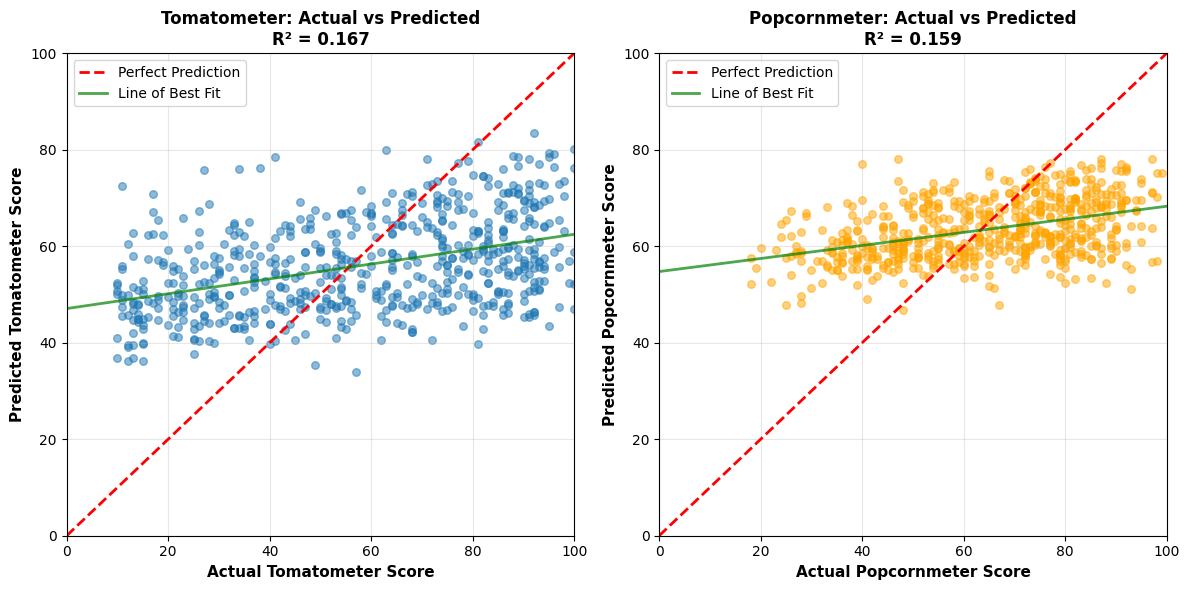

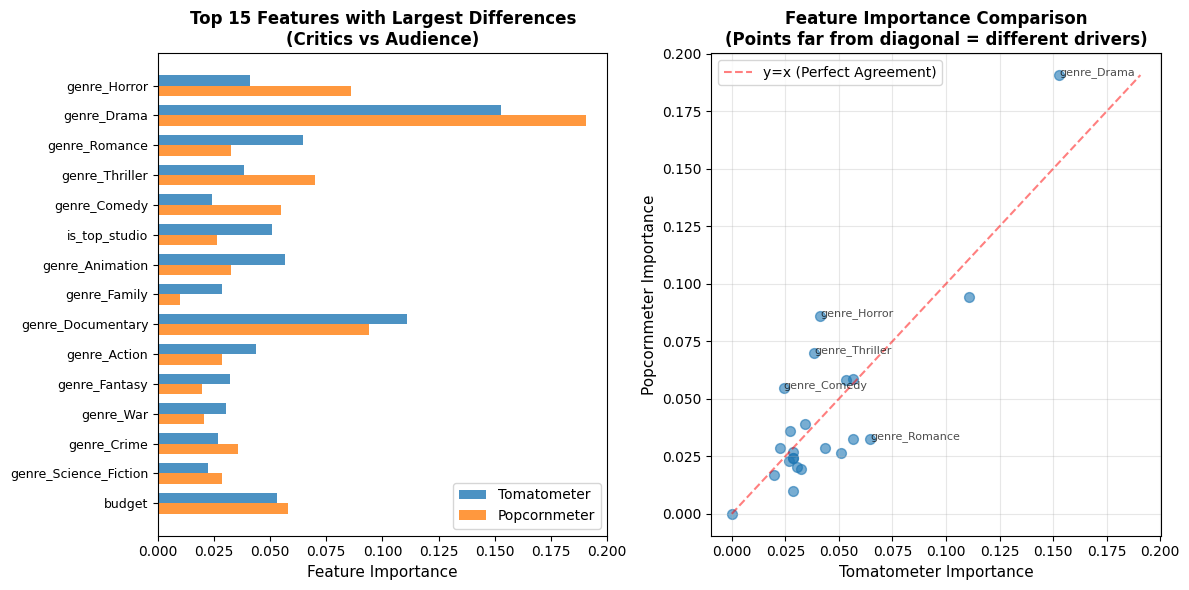


=== Feature Importance Correlation ===
Correlation between Tomatometer and Popcornmeter importances: 0.8631
P-value: 0.000000
Interpretation: HIGH correlation - critics and audiences are driven by similar factors


In [66]:
# Evaluate models
print("\n=== TOMATOMETER Model Performance ===")
print(f"R² Score: {r2_score(y_tom_test, y_tom_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_tom_test, y_tom_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_tom_test, y_tom_pred)):.4f}")

print("\n=== POPCORNMETER Model Performance ===")
print(f"R² Score: {r2_score(y_pop_test, y_pop_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_pop_test, y_pop_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_pop_test, y_pop_pred)):.4f}")

# Feature importance comparison (XGBoost uses feature_importances_ not coefficients)
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Tomatometer_Importance': gb_tom.feature_importances_,
    'Popcornmeter_Importance': gb_pop.feature_importances_
})

importance_df['Abs_Diff'] = abs(importance_df['Tomatometer_Importance'] - importance_df['Popcornmeter_Importance'])
importance_df = importance_df.sort_values('Abs_Diff', ascending=False)

print("\n=== Top 15 Features with LARGEST DIFFERENCES ===")
print("(These drive critics and audiences differently)")
print(importance_df.head(15).to_string())

print("\n=== Top 10 Most Important for TOMATOMETER ===")
top_tom = importance_df.sort_values('Tomatometer_Importance', ascending=False).head(10)
print(top_tom[['Feature', 'Tomatometer_Importance']].to_string())

print("\n=== Top 10 Most Important for POPCORNMETER ===")
top_pop = importance_df.sort_values('Popcornmeter_Importance', ascending=False).head(10)
print(top_pop[['Feature', 'Popcornmeter_Importance']].to_string())

# Visualization 1: Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Tomatometer: Actual vs Predicted
axes[0].scatter(y_tom_test, y_tom_pred, alpha=0.5, s=30)
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')

# Add line of best fit
z_tom = np.polyfit(y_tom_test, y_tom_pred, 1)
p_tom = np.poly1d(z_tom)
x_line = np.linspace(0, 100, 100)
axes[0].plot(x_line, p_tom(x_line), 'g-', linewidth=2, alpha=0.7, label='Line of Best Fit')

axes[0].set_xlabel('Actual Tomatometer Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Tomatometer Score', fontsize=11, fontweight='bold')
axes[0].set_title(f'Tomatometer: Actual vs Predicted\nR² = {r2_score(y_tom_test, y_tom_pred):.3f}', 
                     fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Popcornmeter: Actual vs Predicted
axes[1].scatter(y_pop_test, y_pop_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')

# Add line of best fit
z_pop = np.polyfit(y_pop_test, y_pop_pred, 1)
p_pop = np.poly1d(z_pop)
axes[1].plot(x_line, p_pop(x_line), 'g-', linewidth=2, alpha=0.7, label='Line of Best Fit')

axes[1].set_xlabel('Actual Popcornmeter Score', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Popcornmeter Score', fontsize=11, fontweight='bold')
axes[1].set_title(f'Popcornmeter: Actual vs Predicted\nR² = {r2_score(y_pop_test, y_pop_pred):.3f}', 
                     fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Visualization 2: Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Top features by absolute difference
top_diff = importance_df.head(15)
x = np.arange(len(top_diff))
width = 0.35

axes[0].barh(x - width/2, top_diff['Tomatometer_Importance'], width, label='Tomatometer', alpha=0.8)
axes[0].barh(x + width/2, top_diff['Popcornmeter_Importance'], width, label='Popcornmeter', alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top_diff['Feature'], fontsize=9)
axes[0].set_xlabel('Feature Importance', fontsize=11)
axes[0].set_title('Top 15 Features with Largest Differences\n(Critics vs Audience)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# Plot 2: Scatter plot of feature importances
axes[1].scatter(importance_df['Tomatometer_Importance'], 
               importance_df['Popcornmeter_Importance'], 
               alpha=0.6, s=50)
max_val = max(importance_df['Tomatometer_Importance'].max(), importance_df['Popcornmeter_Importance'].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y=x (Perfect Agreement)')
axes[1].set_xlabel('Tomatometer Importance', fontsize=11)
axes[1].set_ylabel('Popcornmeter Importance', fontsize=11)
axes[1].set_title('Feature Importance Comparison\n(Points far from diagonal = different drivers)', 
                 fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Annotate outliers
outliers = importance_df.nlargest(5, 'Abs_Diff')
for _, row in outliers.iterrows():
    axes[1].annotate(row['Feature'], 
                    (row['Tomatometer_Importance'], row['Popcornmeter_Importance']),
                    fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Statistical test: Are the importances significantly different?
corr, p_val = pearsonr(importance_df['Tomatometer_Importance'], importance_df['Popcornmeter_Importance'])
print(f"\n=== Feature Importance Correlation ===")
print(f"Correlation between Tomatometer and Popcornmeter importances: {corr:.4f}")
print(f"P-value: {p_val:.6f}")
if corr > 0.7:
    print("Interpretation: HIGH correlation - critics and audiences are driven by similar factors")
elif corr > 0.3:
    print("Interpretation: MODERATE correlation - some overlap but notable differences")
else:
    print("Interpretation: LOW correlation - critics and audiences are driven by DIFFERENT factors")